<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 4</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.
</p>

<ul>
    <li>Criterion: MSE Loss</li>
    <li>Fully Connected Layers x 2</li>
    <li>Batch Size: 8</li>
    <li>Optimizer: SGD</li>
    <li>Epoch: 1000</li>
</ul>
</div>

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np



In [54]:
# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

n_samples    = 1000
n_features   = 5
noise_std    = 0.5

# True underlying parameters
true_w = np.array([2.0, -1.5, 0.8, 3.0, -0.5])   # shape (5,)
true_b = 1.2

# Random features
X = np.random.randn(n_samples, n_features).astype(np.float32)

# Target = linear combination + bias + gaussian noise
y = X @ true_w + true_b + noise_std * np.random.randn(n_samples).astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 targets:", y[:5])

X shape: (1000, 5)
y shape: (1000,)
First 5 targets: [ 7.39326186 -2.92955551 -4.60987433 -0.33689598  0.88834593]


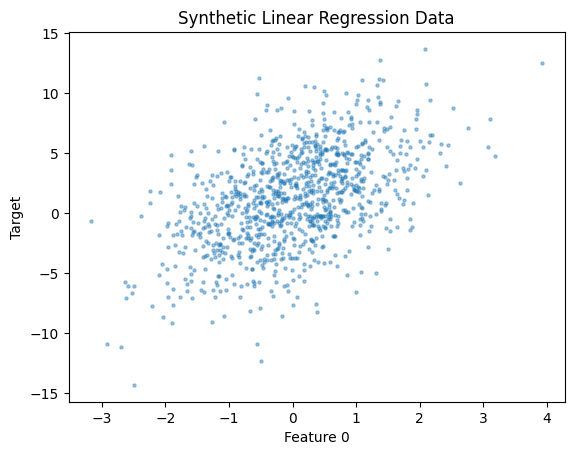

In [55]:
plt.scatter(X[:, 0], y, s=5, alpha=0.4)
plt.xlabel("Feature 0")
plt.ylabel("Target")
plt.title("Synthetic Linear Regression Data")
plt.show()

In [56]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [59]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [60]:
class LinearRegressionNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 16)   # fully connected layer 1
        self.fc2 = nn.Linear(16, 1)             # fully connected layer 2 (output)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

model = LinearRegressionNet(in_features=X.shape[1])

In [61]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 1000

In [62]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_dataset)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {epoch_loss:.4f}")

Epoch [100/1000]  Loss: 0.2685
Epoch [200/1000]  Loss: 0.2662
Epoch [300/1000]  Loss: 0.2651
Epoch [400/1000]  Loss: 0.2633
Epoch [500/1000]  Loss: 0.2675
Epoch [600/1000]  Loss: 0.2661
Epoch [700/1000]  Loss: 0.2661
Epoch [800/1000]  Loss: 0.2643
Epoch [900/1000]  Loss: 0.2656
Epoch [1000/1000]  Loss: 0.2668


In [63]:
model.eval()
with torch.no_grad():
    preds = model(X_test)
    test_loss = criterion(preds, y_test).item()

print(f"\nFinal Test MSE: {test_loss:.4f}")


Final Test MSE: 0.2403
